bounded ReLU - ограниченный ReLU, где активация ограничена сверху порогом $a$ во избежание взрыва градиентов.$$f(x) = \min(a, \max(0, x))$$

# 1. архитектура сети (полносвязный слой, BReLU, Sigmoid)
мы используем объектно-ориентированный подход, аналогичный архитектуре под капотом PyTorch. у каждого слоя есть методы forward и backward

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification

# --- БАЗОВЫЕ СЛОИ И АКТИВАЦИИ ---

class Dense:
    """
    полносвязный слой (fully connected / linear)
    """
    def __init__(self, in_features, out_features):
        # инициализация весов по методу He (идеально для ReLU-подобных активаций)
        self.W = np.random.randn(in_features, out_features) * np.sqrt(2.0 / in_features)
        self.b = np.zeros((1, out_features))
        self.x = None
        self.dW = None
        self.db = None

    def forward(self, x):
        self.x = x
        return np.dot(x, self.W) + self.b

    def backward(self, dout):
        # градиенты по весам и смещениям
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0, keepdims=True)
        # градиент для передачи на предыдущий слой
        dx = np.dot(dout, self.W.T)
        return dx

class BReLU:
    """
    Bounded ReLU (ограниченный ReLU)
    """
    def __init__(self, a=6.0):
        self.a = a
        self.x = None

    def forward(self, x):
        self.x = x
        # ограничиваем значения диапазоном [0, a]
        return np.clip(x, 0, self.a)

    def backward(self, dout):
        dx = dout.copy()
        # производная равна 0, если x <= 0 или x >= a
        dx[(self.x <= 0) | (self.x >= self.a)] = 0
        return dx

class Sigmoid:
    """
    сигмоида для бинарной классификации
    """
    def __init__(self):
        self.out = None

    def forward(self, x):
        # клиппинг для предотвращения overflow (вычислительная стабильность)
        x_clipped = np.clip(x, -500, 500)
        self.out = 1.0 / (1.0 + np.exp(-x_clipped))
        return self.out

    def backward(self, dout):
        # производная сигмоиды: sigma * (1 - sigma)
        return dout * self.out * (1.0 - self.out)

class Sequential:
    """
    контейнер для сборки сети (выполняет проходы по всем слоям)
    """
    def __init__(self, *layers):
        self.layers = layers

    def forward(self, x):
        out = x
        for layer in self.layers:
            out = layer.forward(out)
        return out

    def backward(self, dout):
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

# 2. SGD с батчами и NAdam (Модификация Adam)
требование использовать связку Momentum/Nesterov + AdaGrad/RMSProp подходит под алгоритм NAdam (Nesterov-accelerated Adaptive Moment Estimation). классический Adam использует обычный Momentum, а NAdam заменяет его на шаг Нестерова, что дает более точное направление градиента.

формула обновления весов с учетом Нестерова выглядит как $$\theta_{t} = \theta_{t-1} - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \left( \beta_1 \hat{m}_t + \frac{1-\beta_1}{1-\beta_1^t} g_t \right)$$

In [ ]:
# --- ГЕНЕРАТОР БАТЧЕЙ ---

def get_batches(X, y, batch_size):
    """
    генератор мини-батчей
    """
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices) # обязательно перемешиваем перед каждой эпохой
    for i in range(0, X.shape[0], batch_size):
        batch_idx = indices[i:i+batch_size]
        yield X[batch_idx], y[batch_idx]

# --- ОПТИМИЗАТОРЫ ---

class NAdam:
    """
    оптимизатор NAdam (Momentum Nesterov + RMSProp)"""
    def __init__(self, layers, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.layers = layers
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = {} # первый момент (Momentum)
        self.v = {} # второй момент (RMSProp)
        self.t = 0  # счетчик шагов

        # инициализация моментов нулями
        for idx, layer in enumerate(self.layers):
            if hasattr(layer, 'W'):
                self.m[f'W{idx}'] = np.zeros_like(layer.W)
                self.v[f'W{idx}'] = np.zeros_like(layer.W)
                self.m[f'b{idx}'] = np.zeros_like(layer.b)
                self.v[f'b{idx}'] = np.zeros_like(layer.b)

    def step(self):
        self.t += 1
        for idx, layer in enumerate(self.layers):
            if hasattr(layer, 'W'):
                dW, db = layer.dW, layer.db

                # --- рбновление для весов (W) ---
                # 1. считаем экспоненциальные скользящие средние (RMSProp + Momentum)
                self.m[f'W{idx}'] = self.beta1 * self.m[f'W{idx}'] + (1 - self.beta1) * dW
                self.v[f'W{idx}'] = self.beta2 * self.v[f'W{idx}'] + (1 - self.beta2) * (dW ** 2)

                # 2. коррекция смещения (Bias correction)
                m_hat_W = self.m[f'W{idx}'] / (1 - self.beta1 ** self.t)
                v_hat_W = self.v[f'W{idx}'] / (1 - self.beta2 ** self.t)

                # 3. применяем Nesterov (предварительный шаг вперед)
                m_nesterov_W = self.beta1 * m_hat_W + (1 - self.beta1) * dW / (1 - self.beta1 ** self.t)

                # 4. дбновляем веса
                layer.W -= self.lr * m_nesterov_W / (np.sqrt(v_hat_W) + self.epsilon)

                # --- обновление лоля смещений (b) - аналогично ---
                self.m[f'b{idx}'] = self.beta1 * self.m[f'b{idx}'] + (1 - self.beta1) * db
                self.v[f'b{idx}'] = self.beta2 * self.v[f'b{idx}'] + (1 - self.beta2) * (db ** 2)

                m_hat_b = self.m[f'b{idx}'] / (1 - self.beta1 ** self.t)
                v_hat_b = self.v[f'b{idx}'] / (1 - self.beta2 ** self.t)

                m_nesterov_b = self.beta1 * m_hat_b + (1 - self.beta1) * db / (1 - self.beta1 ** self.t)
                layer.b -= self.lr * m_nesterov_b / (np.sqrt(v_hat_b) + self.epsilon)

# 3/ генерация датасетов
здесь мы просто используем встроенные инструменты scikit-learn. лол

скажите "скебоб" если правда это читаете на защите

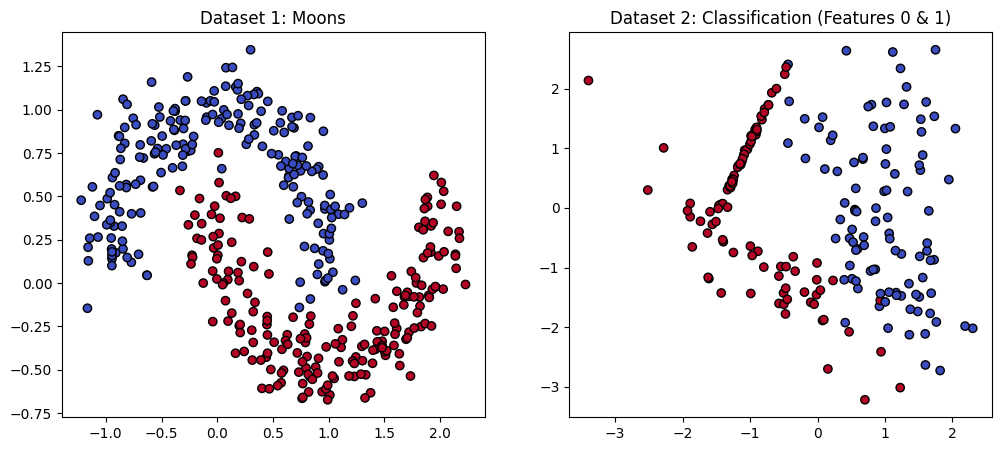

In [ ]:
# --- ГЕНЕРАЦИЯ ДАННЫХ ---

ISU = 465370

# 1) датасет "луны" (нелинейно разделимые данные)
X_moons, y_moons = make_moons(
    n_samples=400,
    noise=0.15,
    random_state=ISU
)

# 2) датасет "улассификация" (с избыточными и информативными признаками)
X_class, y_class = make_classification(
    n_samples=200,
    n_features=5,
    n_redundant=2,
    n_informative=2,
    n_clusters_per_class=2,
    n_classes=2,
    random_state=ISU
)

# графики
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', edgecolors='k')
plt.title('Dataset 1: Moons')

plt.subplot(1, 2, 2)
# для второго датасета выведем первые два признака (проекция)
plt.scatter(X_class[:, 0], X_class[:, 1], c=y_class, cmap='coolwarm', edgecolors='k')
plt.title('Dataset 2: Classification (Features 0 & 1)')

plt.show()